In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras import regularizers

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
csv_path = "/content/drive/MyDrive/autoenc.csv"
df = pd.read_csv("/content/drive/MyDrive/autoenc.csv", header=None)

X_autoenc = df.iloc[:, :8].values
X_autoenc = X_autoenc.astype(float)
print("Autoencoder shape:", X_autoenc.shape)

Autoencoder shape: (98664, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


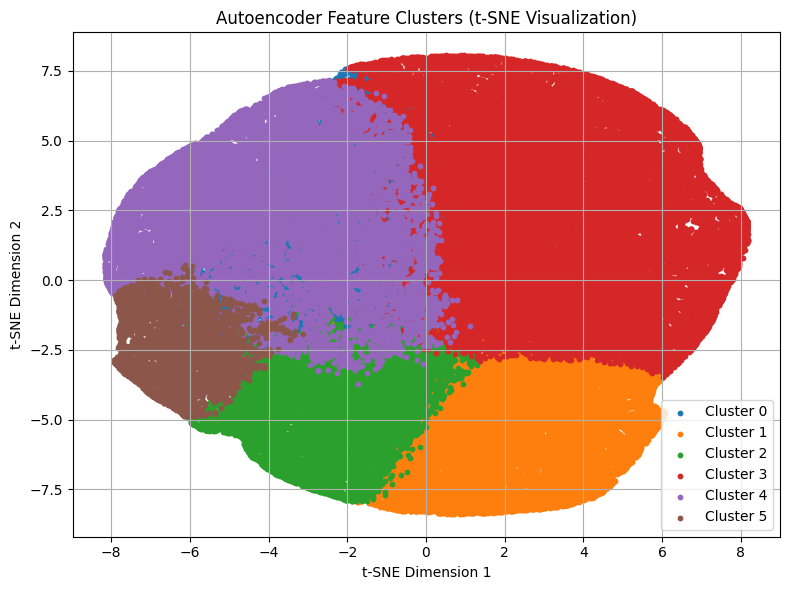

In [ ]:
n_clusters = 6

# KMeans clustering on autoencoded features
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_autoenc)


tsne = TSNE(n_components=2, perplexity=20, learning_rate=150, random_state=42, n_iter=350)
X_tsne = tsne.fit_transform(X_autoenc)

# Scatter plot of clusters
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_tsne[cluster_labels == i, 0],
                X_tsne[cluster_labels == i, 1],
                s=10, label=f'Cluster {i}')

plt.title("Autoencoder Feature Clusters (t-SNE Visualization)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

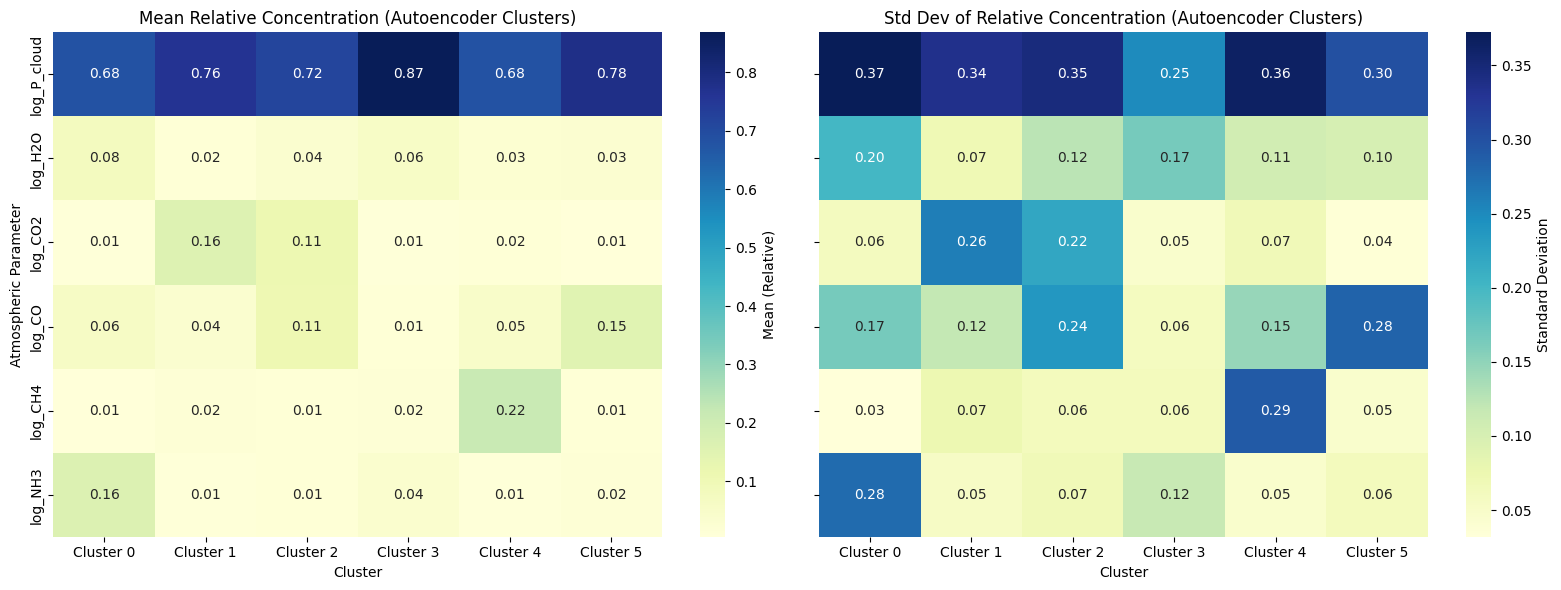

In [ ]:
selected_params = ['log_P_cloud', 'log_H2O', 'log_CO2',
                   'log_CO', 'log_CH4', 'log_NH3']

# Extract atmospheric parameter log values (after first 8 autoenc columns)
log_values = df.iloc[:, 8:].values.astype(float)
params_df = pd.DataFrame(log_values, columns=selected_params)

# Convert to absolute concentrations
abs_values = np.power(10, log_values)

# Compute relative concentrations
rel_conc = abs_values / abs_values.sum(axis=1, keepdims=True)

# Add clusters
rel_df = pd.DataFrame(rel_conc, columns=selected_params)
rel_df['cluster'] = cluster_labels

cluster_means = rel_df.groupby('cluster')[selected_params].mean()
cluster_stds = rel_df.groupby('cluster')[selected_params].std()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0],
            xticklabels=[f'Cluster {i}' for i in cluster_means.index],
            yticklabels=selected_params, cbar_kws={'label': 'Mean (Relative)'})
axes[0].set_title("Mean Relative Concentration (Autoencoder Clusters)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Atmospheric Parameter")

sns.heatmap(cluster_stds.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in cluster_stds.index],
            yticklabels=selected_params, cbar_kws={'label': 'Standard Deviation'})
axes[1].set_title("Std Dev of Relative Concentration (Autoencoder Clusters)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()

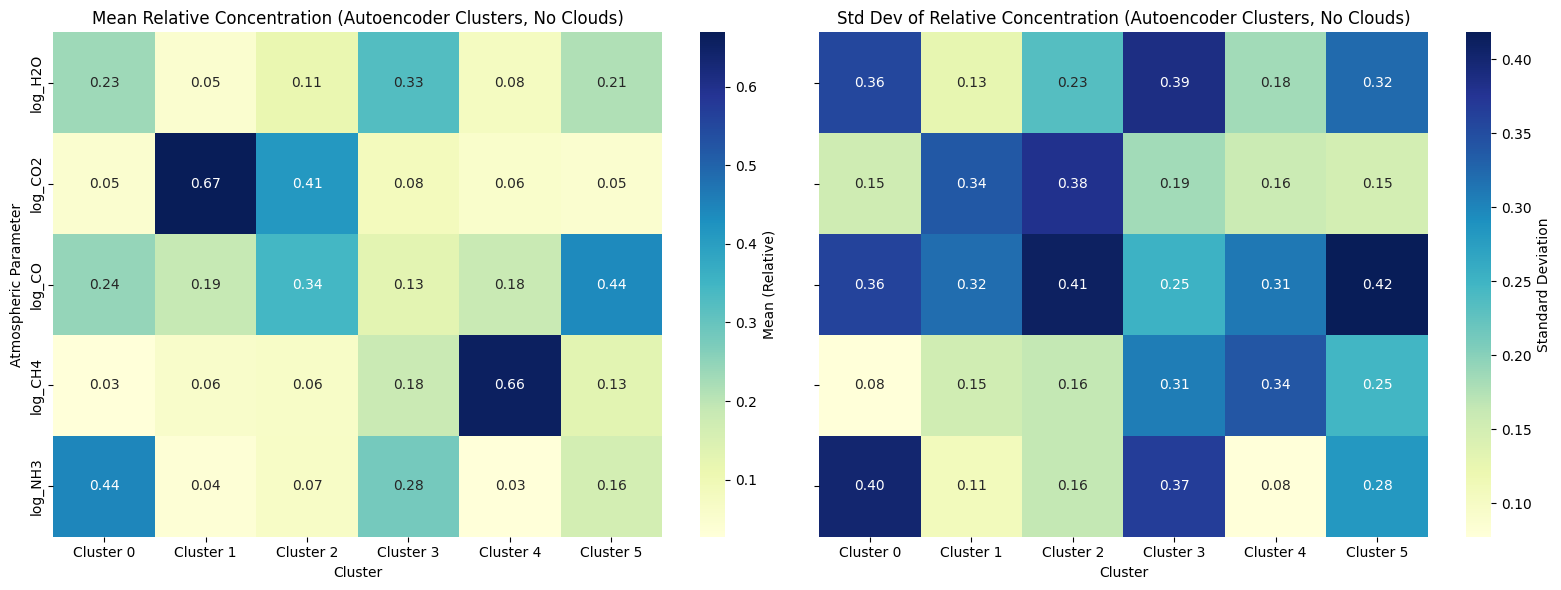

In [ ]:
selected_params = ['log_H2O', 'log_CO2',
                   'log_CO', 'log_CH4', 'log_NH3']

# Create DataFrame of log values
log_values = df.iloc[:, 9:].values.astype(float)
params_df = pd.DataFrame(log_values, columns=selected_params)

abs_values = np.power(10, log_values)

# Compute relative concentrations
rel_conc = abs_values / abs_values.sum(axis=1, keepdims=True)

rel_df = pd.DataFrame(rel_conc, columns=selected_params)
rel_df['cluster'] = cluster_labels

cluster_means = rel_df.groupby('cluster')[selected_params].mean()
cluster_stds = rel_df.groupby('cluster')[selected_params].std()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Mean heatmap
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0],
            xticklabels=[f'Cluster {i}' for i in cluster_means.index],
            yticklabels=selected_params, cbar_kws={'label': 'Mean (Relative)'})
axes[0].set_title("Mean Relative Concentration (Autoencoder Clusters, No Clouds)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Atmospheric Parameter")

# Std deviation heatmap
sns.heatmap(cluster_stds.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in cluster_stds.index],
            yticklabels=selected_params, cbar_kws={'label': 'Standard Deviation'})
axes[1].set_title("Std Dev of Relative Concentration (Autoencoder Clusters, No Clouds)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()

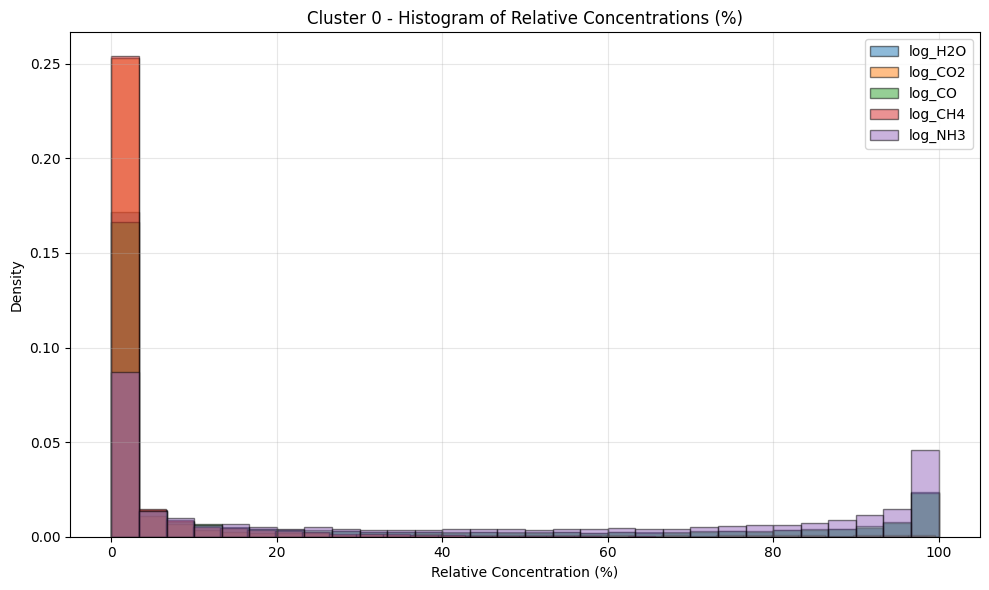

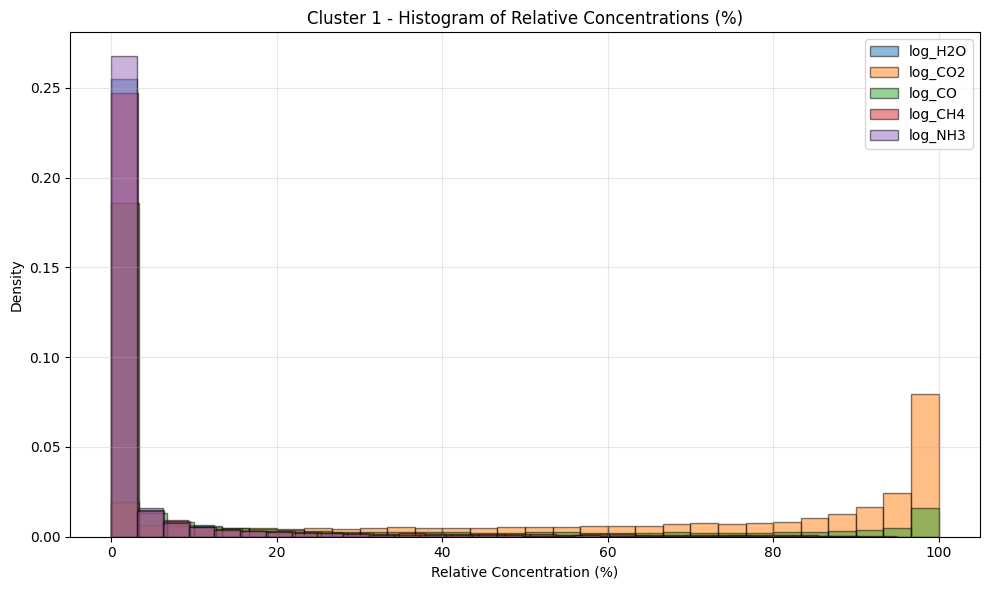

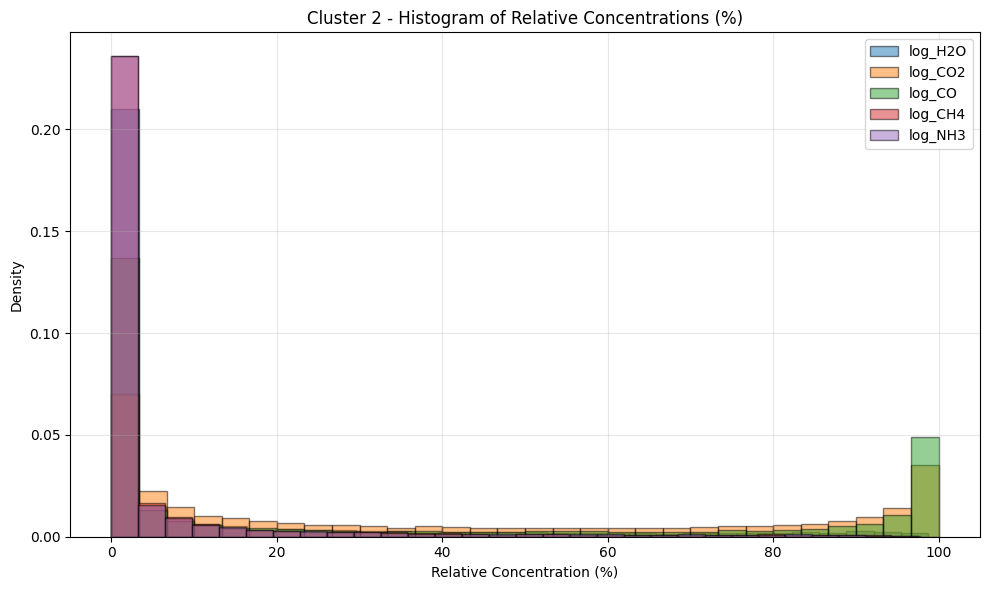

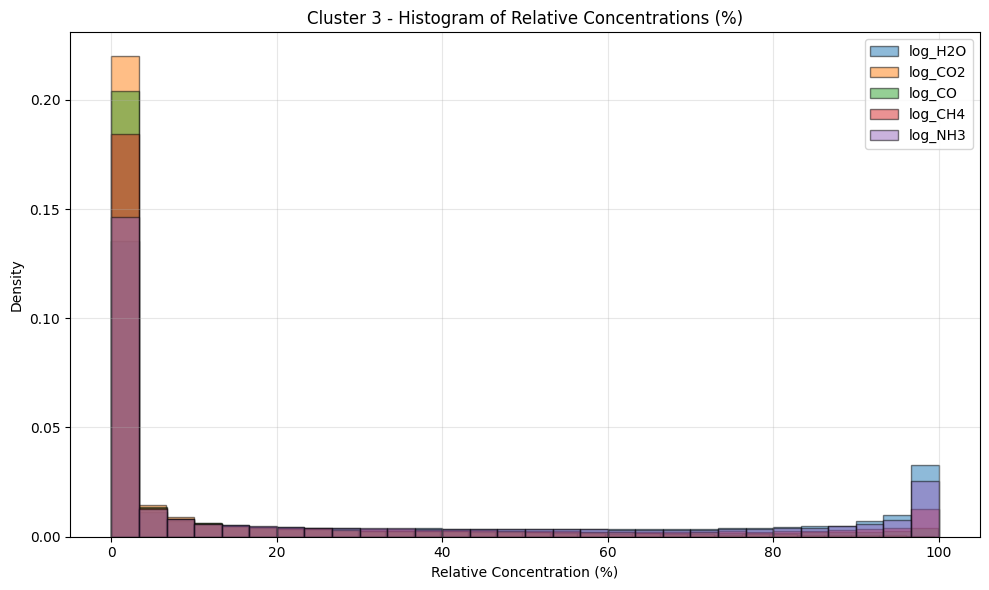

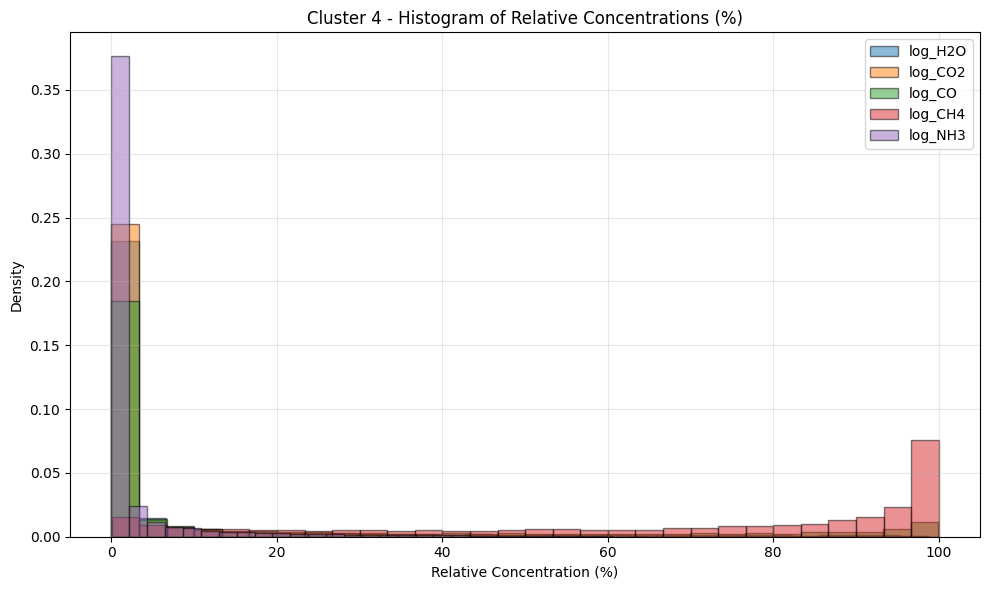

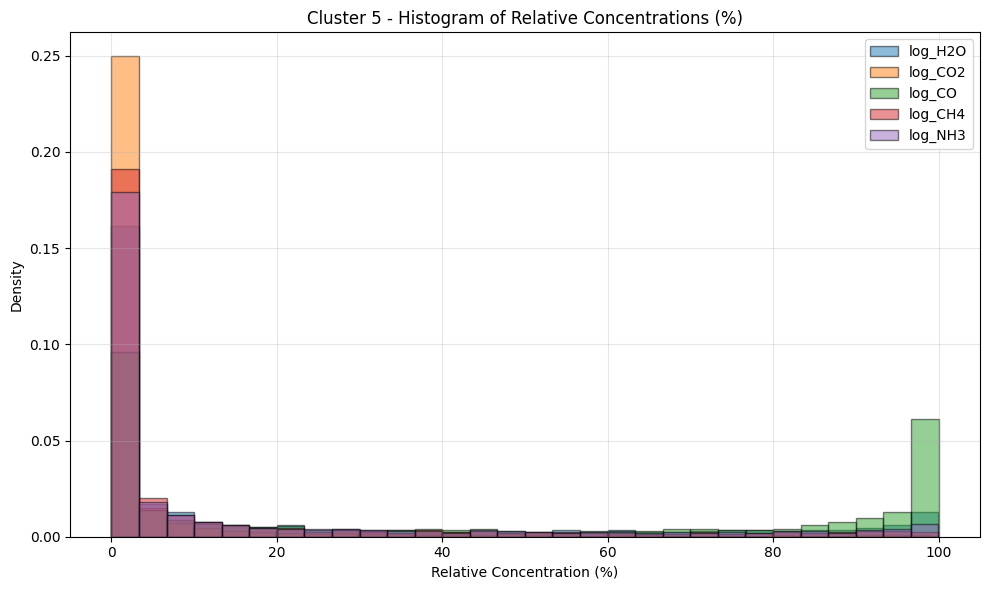

In [ ]:
# Histogram plots per cluster
for cluster_id in sorted(rel_df['cluster'].unique()):
    cluster_data = rel_df[rel_df['cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    for param in selected_params:

        values = cluster_data[param] * 100
        plt.hist(values, bins=30, alpha=0.5, density=True,
                 label=param, edgecolor='black')

    plt.title(f"Cluster {cluster_id} - Histogram of Relative Concentrations (%)")
    plt.xlabel("Relative Concentration (%)")

    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

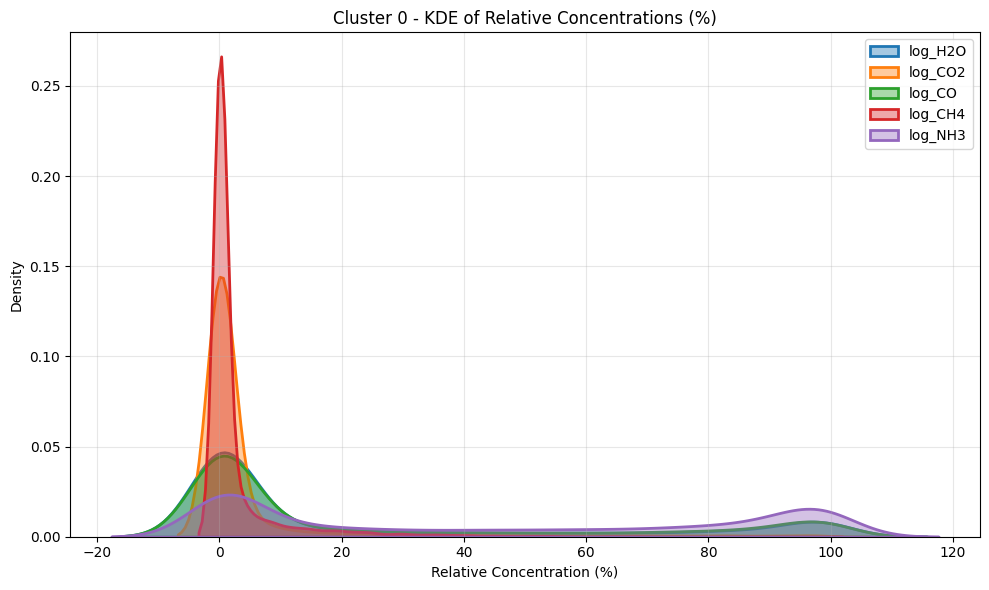

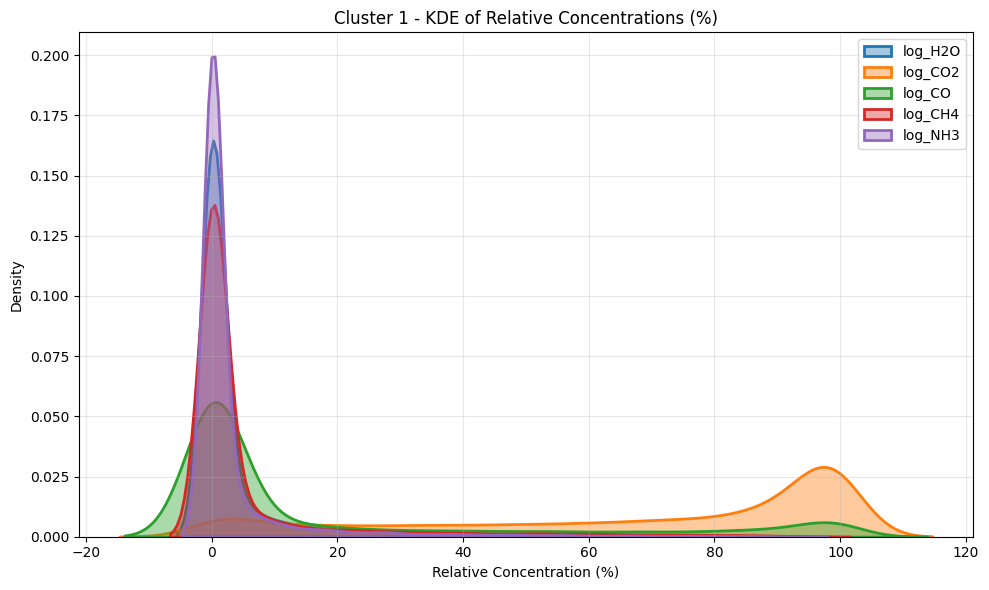

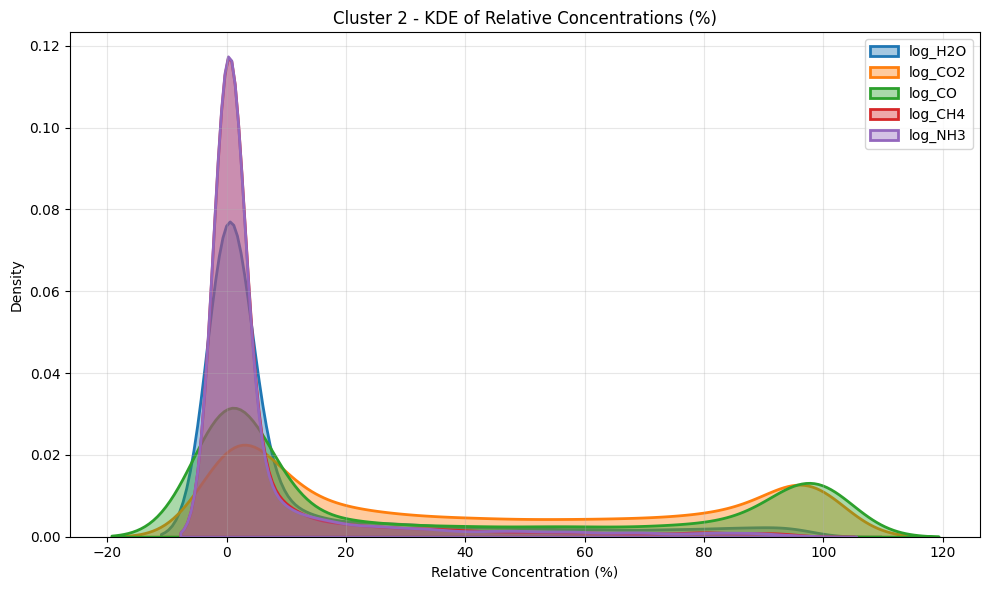

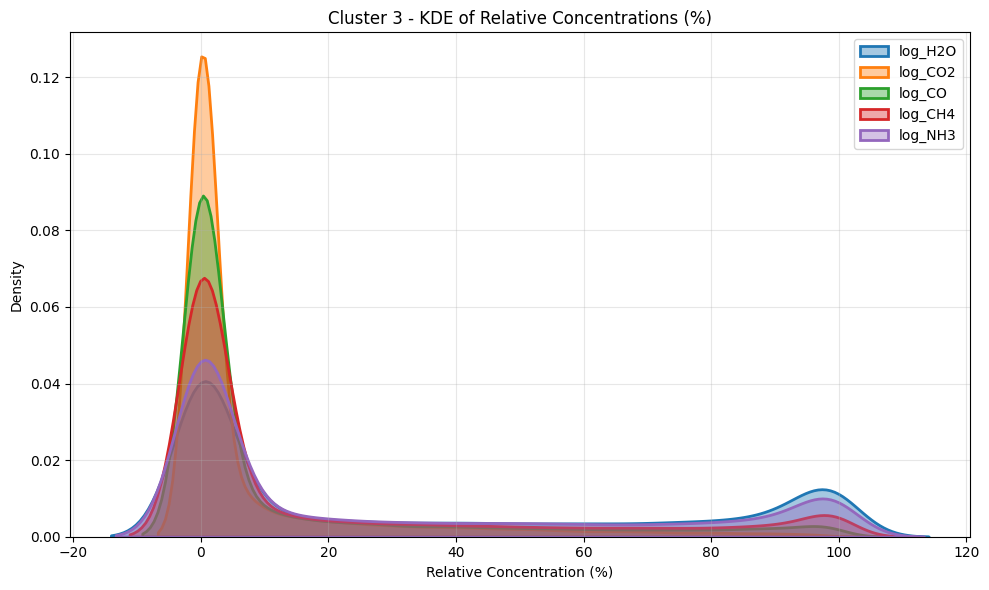

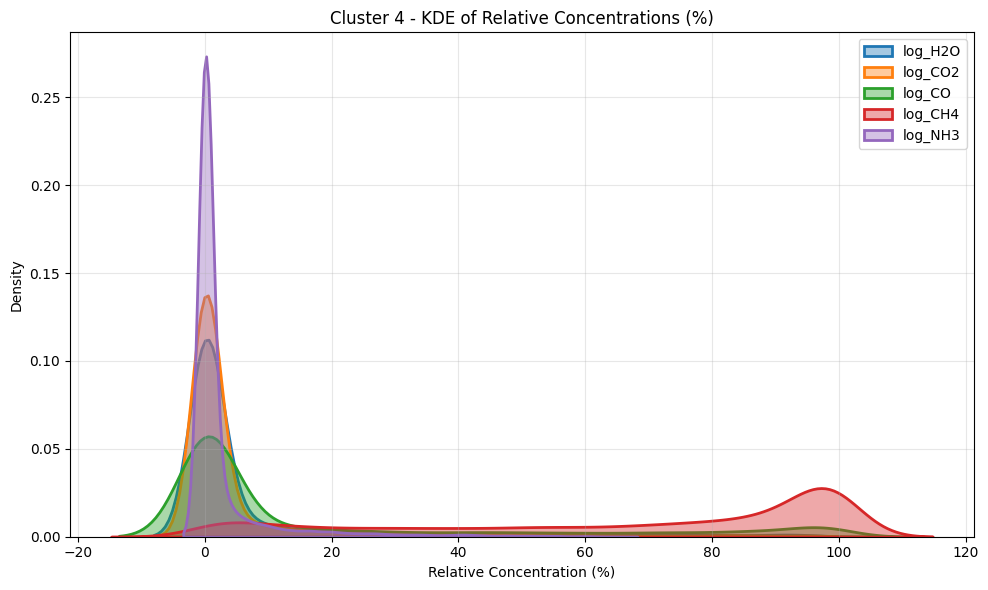

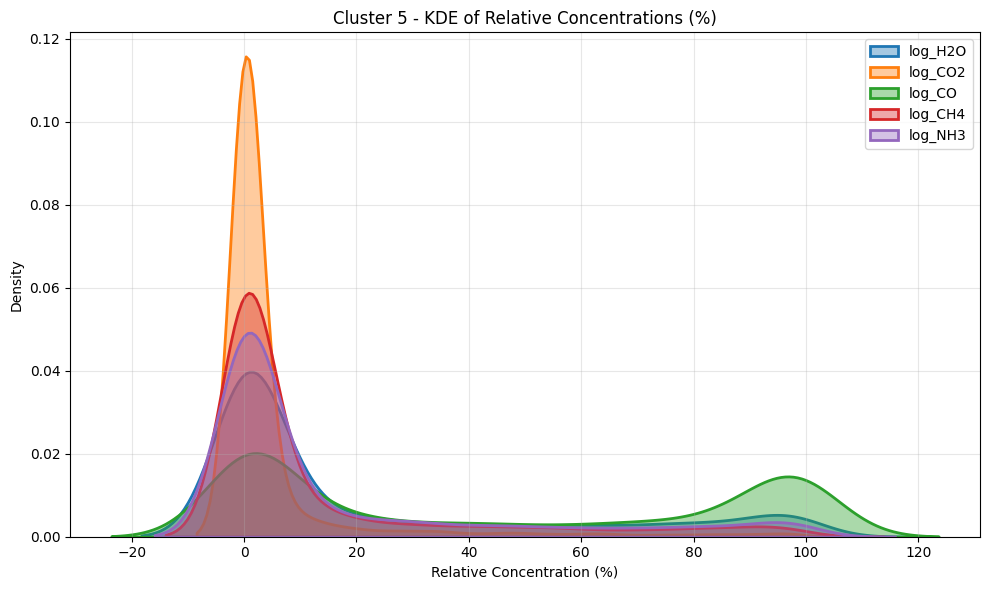

In [ ]:
for cluster_id in sorted(rel_df['cluster'].unique()):
    cluster_data = rel_df[rel_df['cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    for param in selected_params:
        values = cluster_data[param] * 100
        sns.kdeplot(values, label=param, fill=True, alpha=0.4, linewidth=2)

    plt.title(f"Cluster {cluster_id} - KDE of Relative Concentrations (%)")
    plt.xlabel("Relative Concentration (%)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


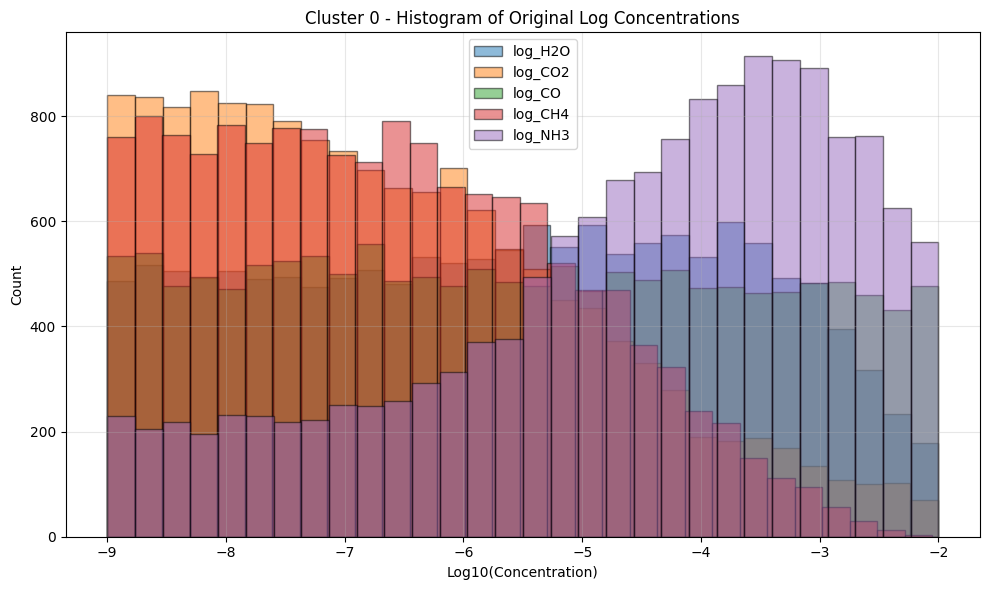

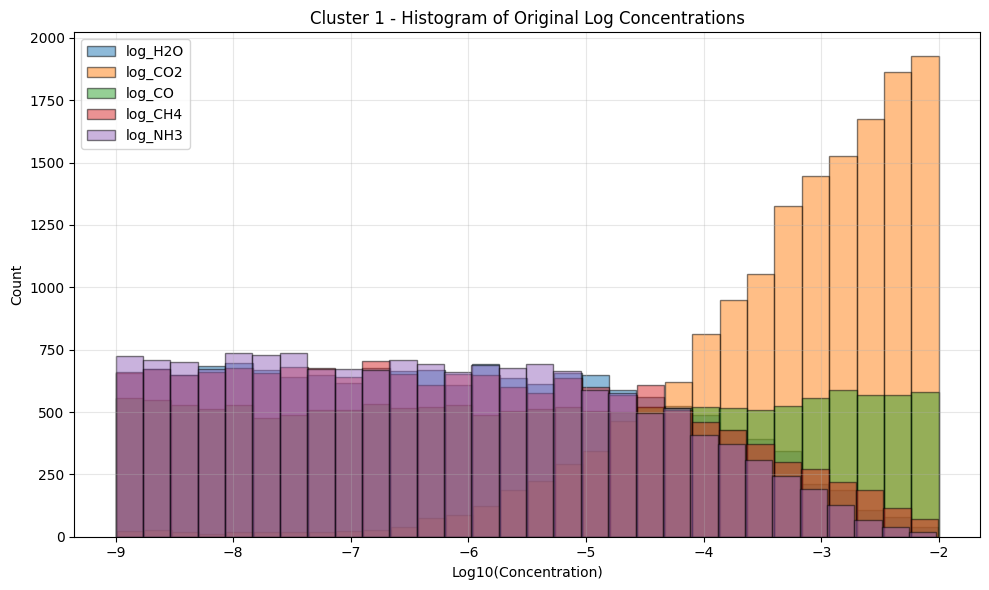

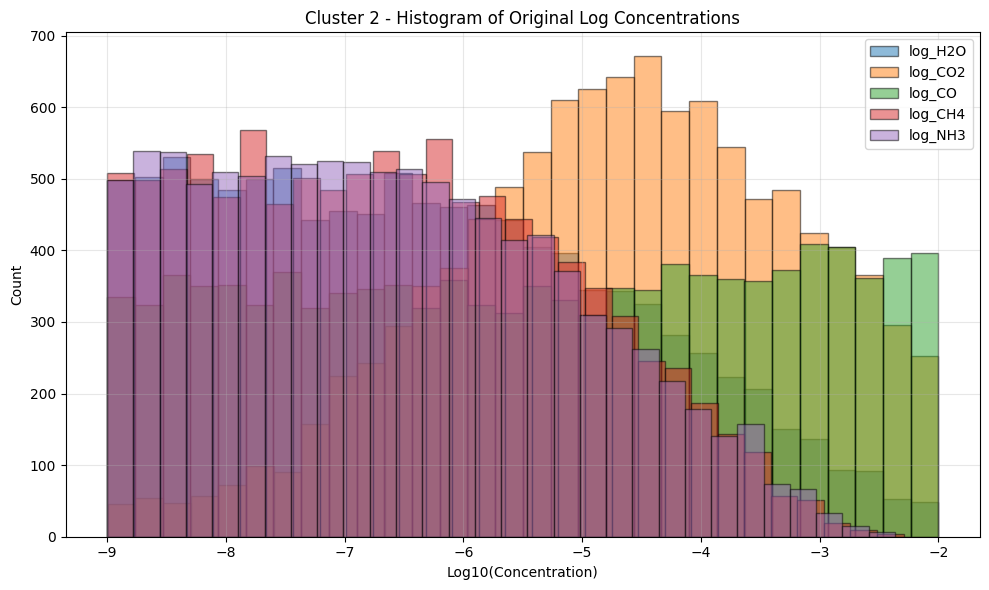

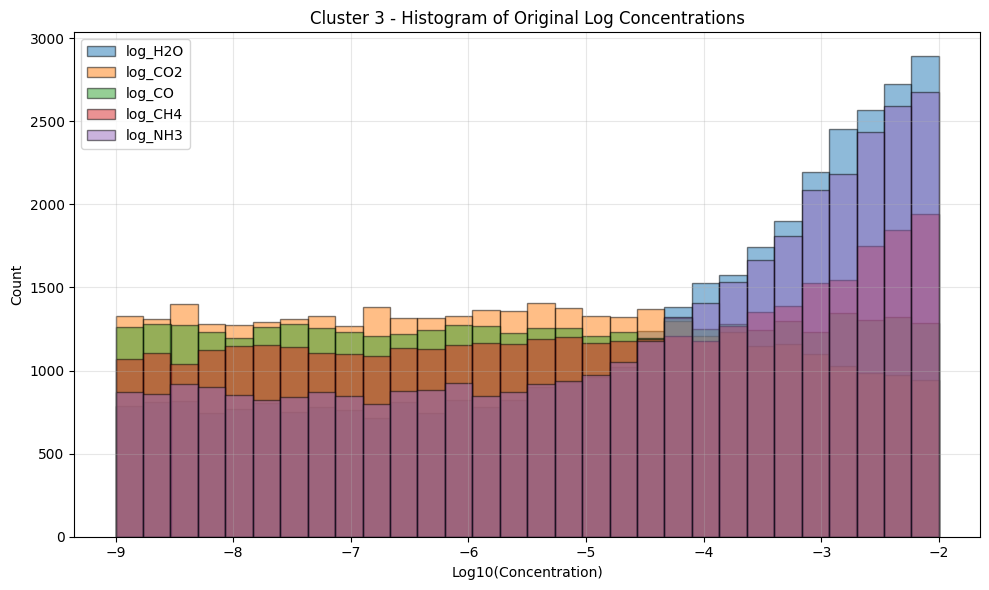

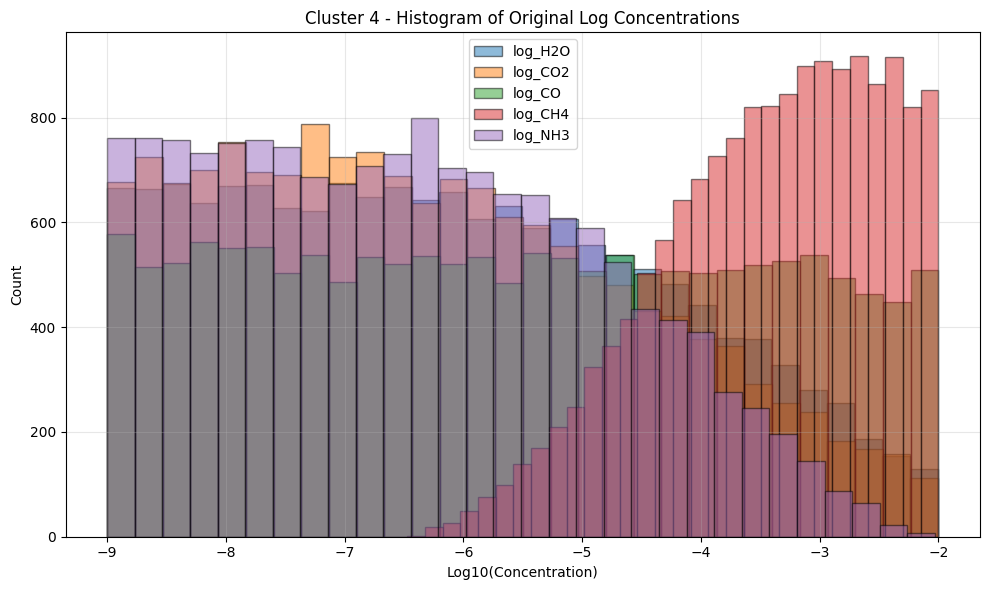

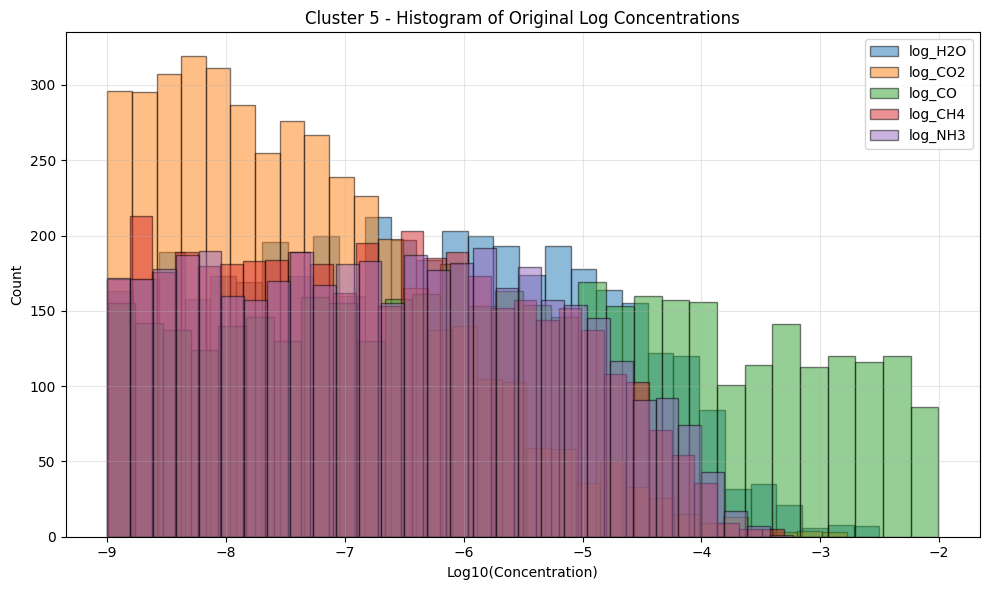

In [ ]:
#  Histogram plots per cluster (original log concentrations)
params_df['cluster'] = cluster_labels

for cluster_id in sorted(params_df['cluster'].unique()):
    cluster_data = params_df[params_df['cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    for param in selected_params:
        plt.hist(cluster_data[param], bins=30, alpha=0.5, label=param, edgecolor='black')

    plt.title(f"Cluster {cluster_id} - Histogram of Original Log Concentrations")
    plt.xlabel("Log10(Concentration)")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
filtered_rel_df = rel_df[rel_df[selected_params].max(axis=1) >= 0.70].copy()

print("Original shape:", rel_df.shape)
print("Filtered shape:", filtered_rel_df.shape)

Original shape: (98664, 6)
Filtered shape: (70559, 6)


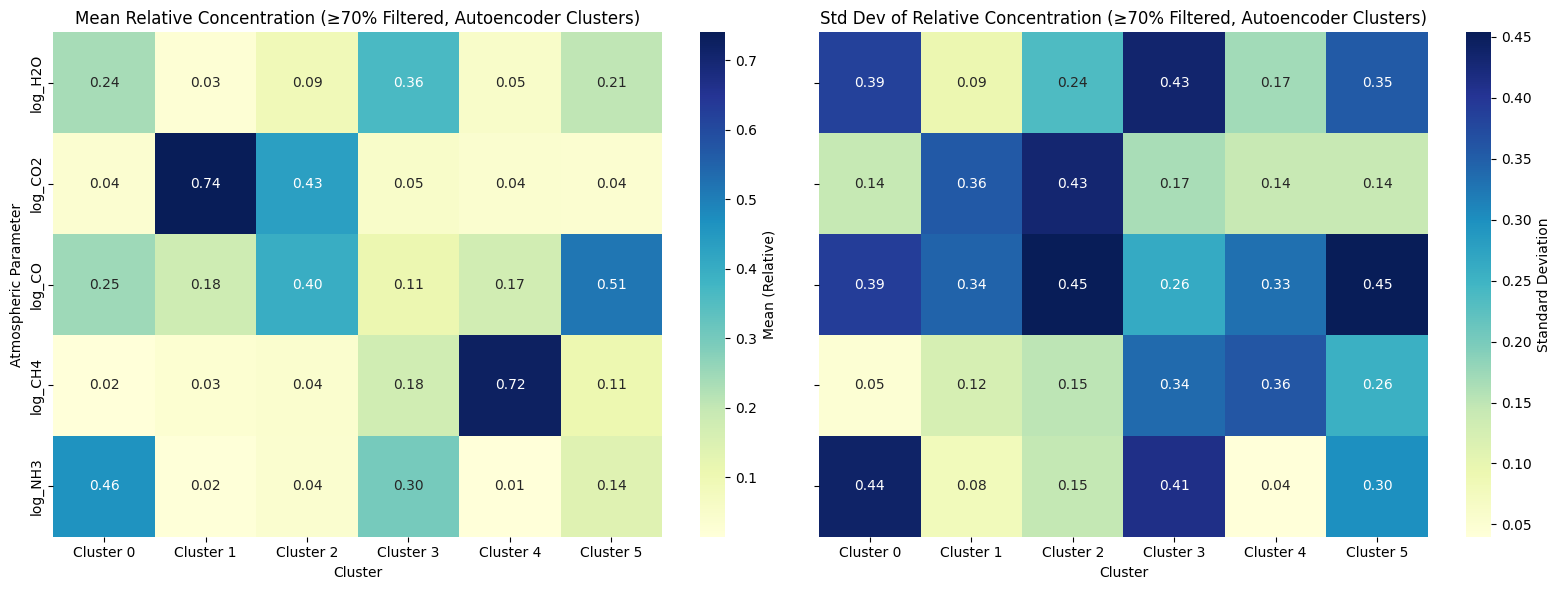

In [ ]:
filtered_cluster_means = filtered_rel_df.groupby('cluster')[selected_params].mean()
filtered_cluster_stds = filtered_rel_df.groupby('cluster')[selected_params].std()


fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Mean heatmap
sns.heatmap(filtered_cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0],
            xticklabels=[f'Cluster {i}' for i in filtered_cluster_means.index],
            yticklabels=selected_params, cbar_kws={'label': 'Mean (Relative)'})
axes[0].set_title("Mean Relative Concentration (≥70% Filtered, Autoencoder Clusters)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Atmospheric Parameter")

# Std deviation heatmap
sns.heatmap(filtered_cluster_stds.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in filtered_cluster_stds.index],
            yticklabels=selected_params, cbar_kws={'label': 'Standard Deviation'})
axes[1].set_title("Std Dev of Relative Concentration (≥70% Filtered, Autoencoder Clusters)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()

In [ ]:
selected_params = ['log_P_cloud', 'log_H2O', 'log_CO2',
                   'log_CO', 'log_CH4', 'log_NH3']

log_values = df.iloc[:, 8:14].values.astype(float)

# Convert to absolute
abs_values = np.power(10, log_values)

# Compute relative concentrations
rel_conc = abs_values / abs_values.sum(axis=1, keepdims=True)

rel_df = pd.DataFrame(rel_conc, columns=selected_params)

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 112.3 MB/s eta 0:00:00


In [ ]:
import pennylane as qml

In [ ]:
# Ampitude Encoding

norms = np.linalg.norm(X_autoenc, axis=1, keepdims=True)
X_amp_normalized = X_autoenc / norms

# Quantum device with 3 qubits
n_qubits = 3
dev = qml.device("default.qubit", wires=n_qubits)

# Amplitude embedding
@qml.qnode(dev)
def amplitude_encode(x):
    qml.AmplitudeEmbedding(x, wires=range(n_qubits), normalize=False)
    return qml.state()

# Encode all samples
encoded_states = []
N = X_amp_normalized.shape[0]
for i in range(N):
    state = amplitude_encode(X_amp_normalized[i])
    encoded_states.append(state)

encoded_states = np.array(encoded_states)
print("Encoded quantum states shape (amp):", encoded_states.shape)


Encoded quantum states shape (amp): (98664, 8)


In [ ]:
quantum_real = np.real(encoded_states)
#quantum_imag = np.imag(encoded_states)

# Concatenate for clustering
#quantum_full = np.hstack([quantum_real, quantum_imag])
quantum_full = quantum_real
print("Quantum full shape:", quantum_full.shape)

Quantum full shape: (98664, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


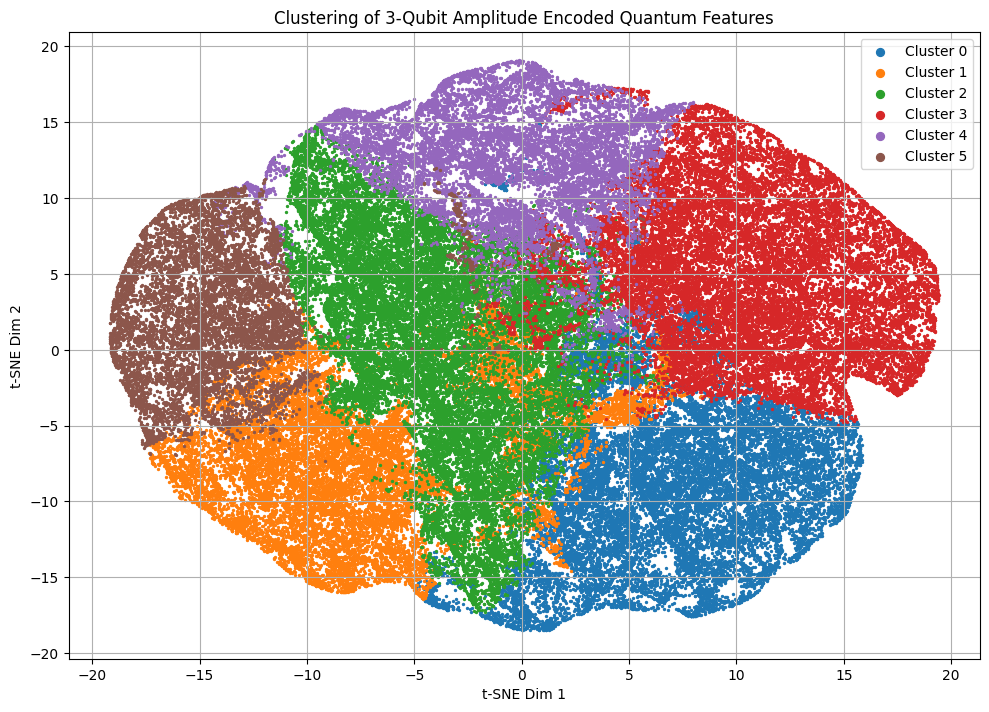

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(quantum_full)

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=0)
labels = kmeans.fit_predict(X_scaled)

# t-SNE visualization
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=0, n_iter=500)
X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE with cluster labels
plt.figure(figsize=(10, 7))
for i in range(6):
    cluster_points = X_tsne[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=2, label=f'Cluster {i}')

plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.legend(markerscale=4)
plt.grid(True)
plt.tight_layout()
plt.title("Clustering of 3-Qubit Amplitude Encoded Quantum Features")
plt.show()

In [ ]:
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score (Amplitude Encoding, 6 Clusters): {score:.4f}")

Silhouette Score (Amplitude Encoding, 6 Clusters): 0.2528


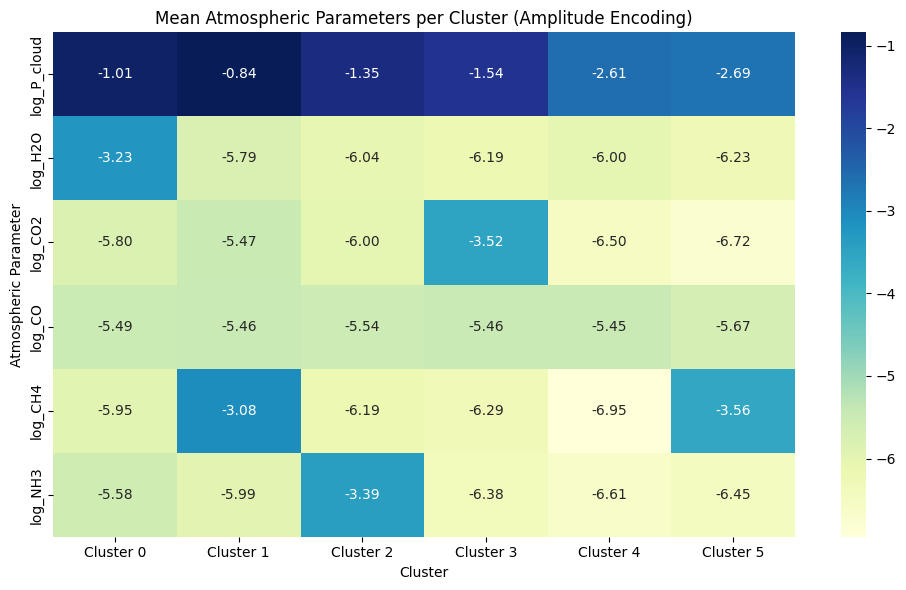

In [ ]:
params = df.iloc[:, 8:14].values.astype(float)
# Create parameter DataFrame
params_df = pd.DataFrame(params, columns=selected_params)
params_df['cluster'] = labels

# Compute mean per cluster
cluster_means = params_df.groupby('cluster')[selected_params].mean()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu',
            xticklabels=[f'Cluster {i}' for i in cluster_means.index],
            yticklabels=selected_params)

plt.title("Mean Atmospheric Parameters per Cluster (Amplitude Encoding)")
plt.xlabel("Cluster")
plt.ylabel("Atmospheric Parameter")
plt.tight_layout()
plt.show()

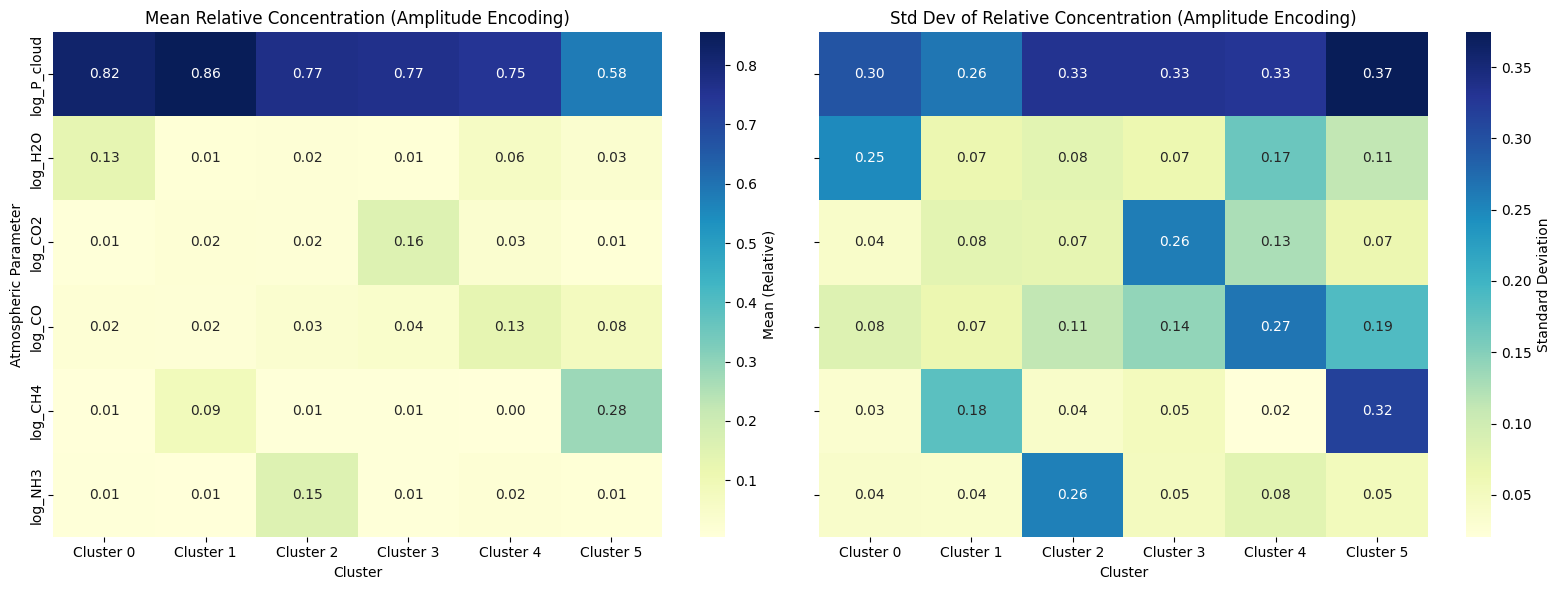

In [ ]:
rel_df['cluster'] = labels

# Compute mean and std of relative concentrations per cluster
cluster_means = rel_df.groupby('cluster')[selected_params].mean()
cluster_stds = rel_df.groupby('cluster')[selected_params].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Mean heatmap
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0],
            xticklabels=[f'Cluster {i}' for i in cluster_means.index],
            yticklabels=selected_params, cbar_kws={'label': 'Mean (Relative)'})
axes[0].set_title("Mean Relative Concentration (Amplitude Encoding)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Atmospheric Parameter")

# Std deviation heatmap
sns.heatmap(cluster_stds.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in cluster_stds.index],
            yticklabels=selected_params, cbar_kws={'label': 'Standard Deviation'})
axes[1].set_title("Std Dev of Relative Concentration (Amplitude Encoding)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()

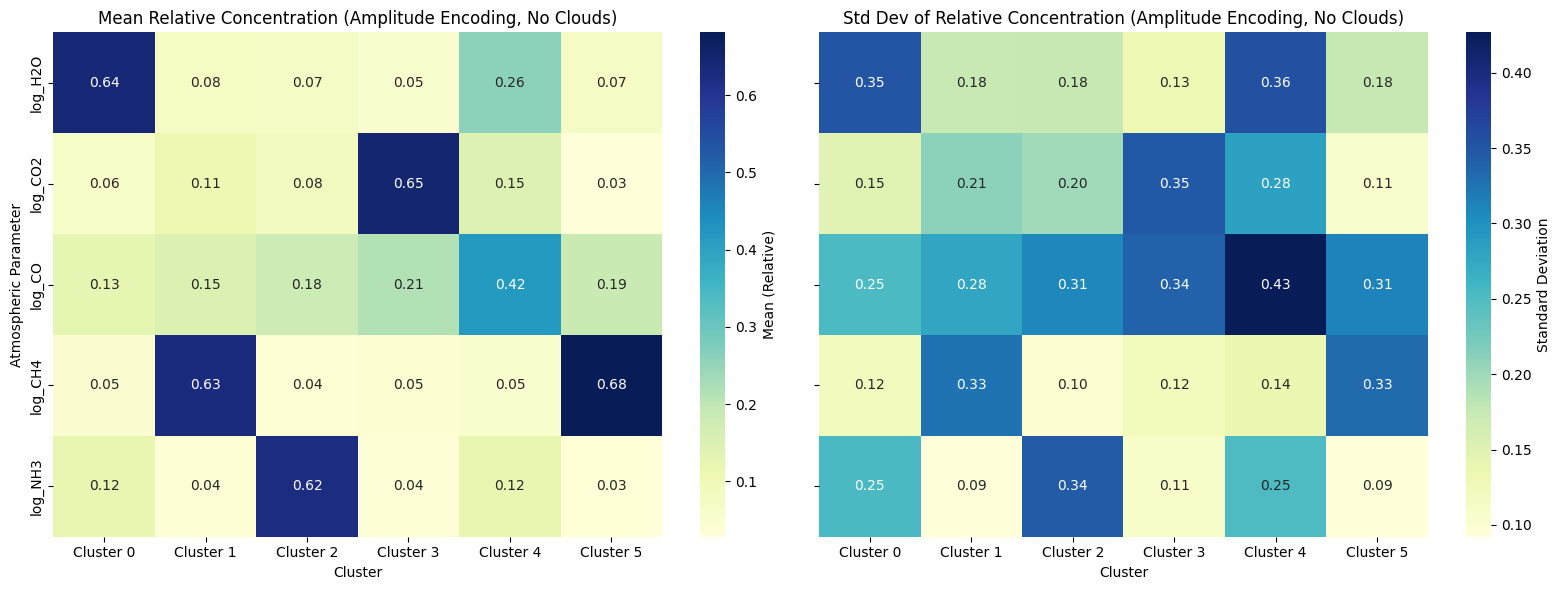

In [ ]:
# Parameters without clouds
selected_params = ['log_H2O', 'log_CO2', 'log_CO', 'log_CH4', 'log_NH3']

# Extract only these columns
params = df.iloc[:, 9:14].values.astype(float)

abs_values = np.power(10, params)

# Compute relative concentrations
rel_conc = abs_values / abs_values.sum(axis=1, keepdims=True)

rel_df = pd.DataFrame(rel_conc, columns=selected_params)
rel_df['cluster'] = labels

# Compute mean and std per cluster
cluster_means = rel_df.groupby('cluster')[selected_params].mean()
cluster_stds = rel_df.groupby('cluster')[selected_params].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Mean heatmap
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0],
            xticklabels=[f'Cluster {i}' for i in cluster_means.index],
            yticklabels=selected_params, cbar_kws={'label': 'Mean (Relative)'})
axes[0].set_title("Mean Relative Concentration (Amplitude Encoding, No Clouds)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Atmospheric Parameter")

# Std deviation heatmap
sns.heatmap(cluster_stds.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in cluster_stds.index],
            yticklabels=selected_params, cbar_kws={'label': 'Standard Deviation'})
axes[1].set_title("Std Dev of Relative Concentration (Amplitude Encoding, No Clouds)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()


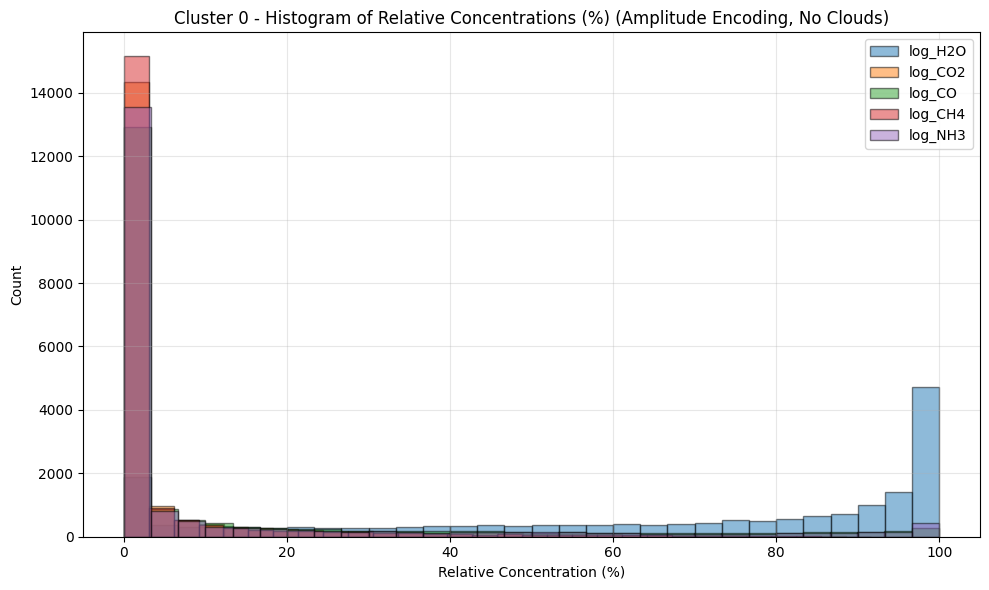

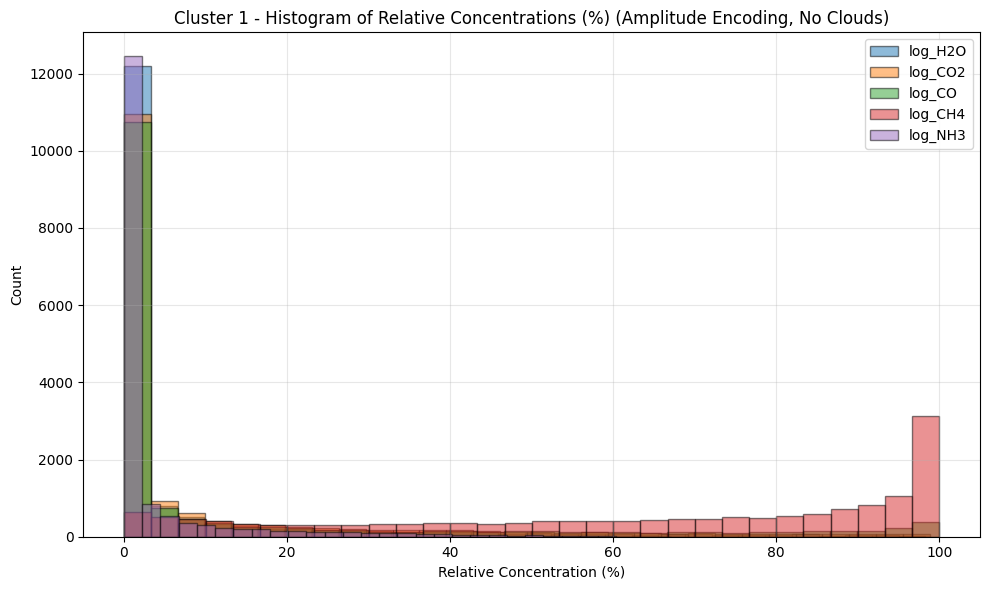

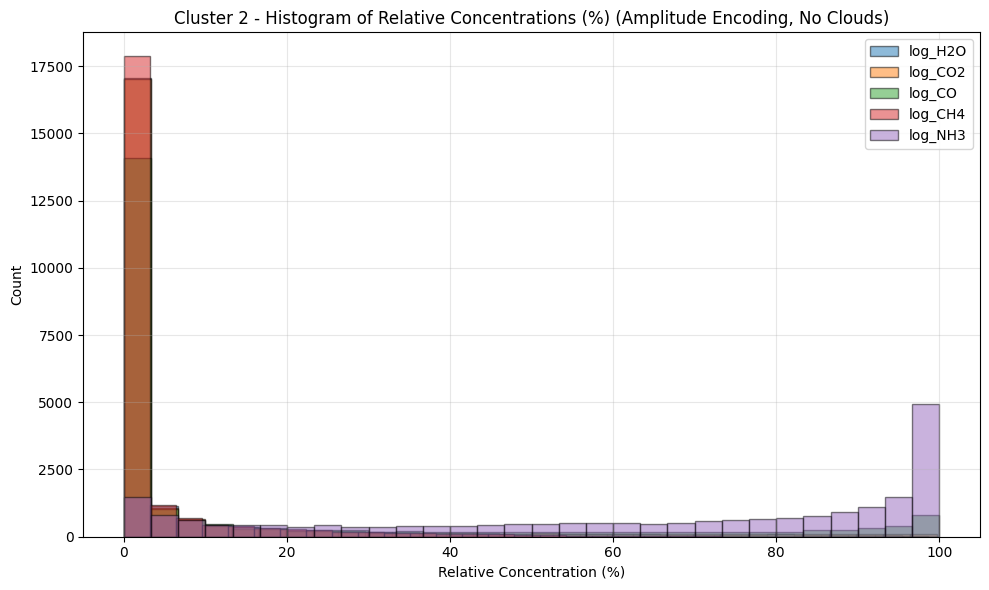

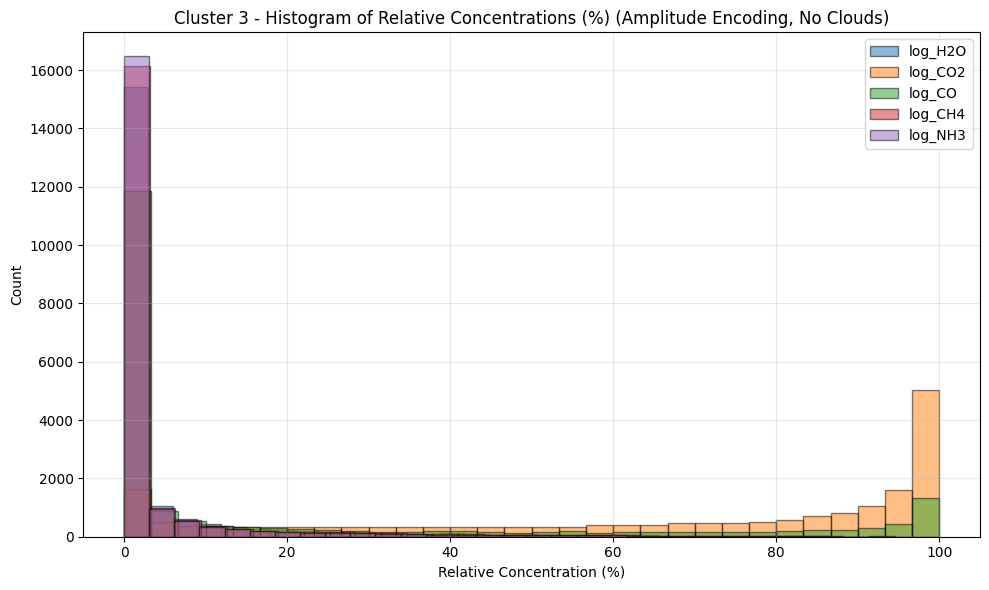

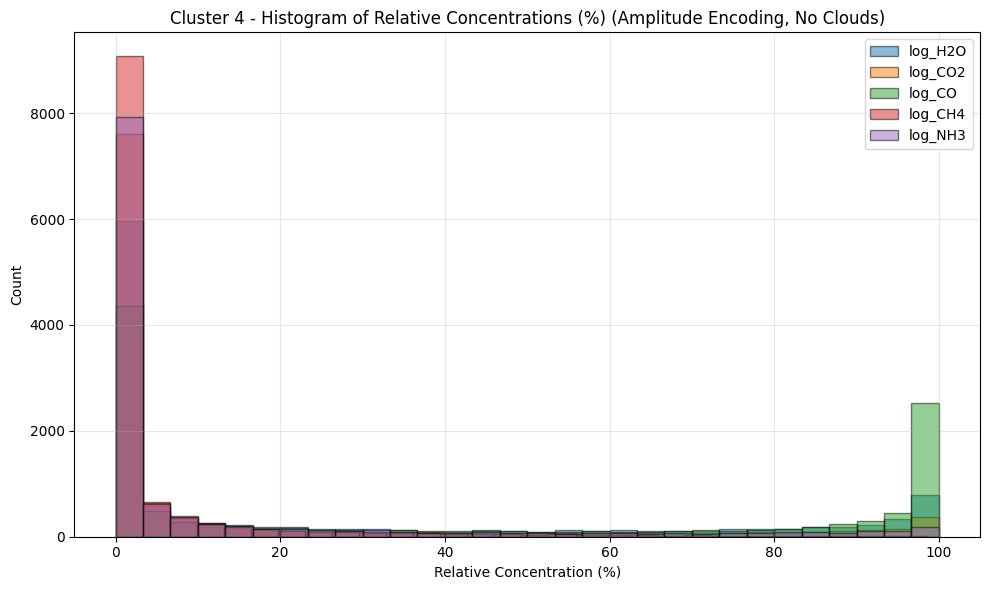

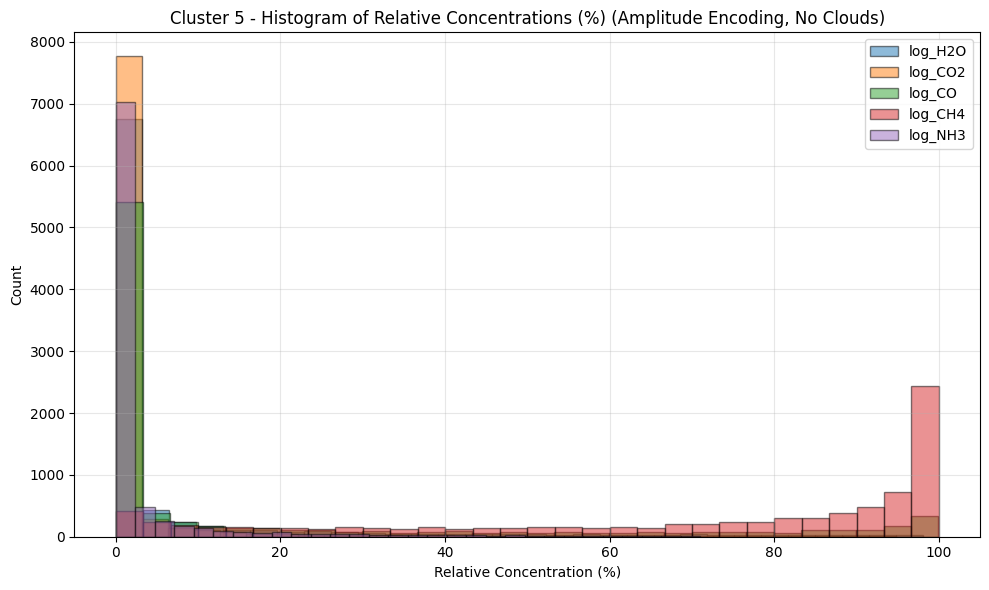

In [ ]:
for cluster_id in sorted(rel_df['cluster'].unique()):
    cluster_data = rel_df[rel_df['cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    for param in selected_params:
        values = cluster_data[param] * 100
        plt.hist(values, bins=30, alpha=0.5, label=param, edgecolor='black')

    plt.title(f"Cluster {cluster_id} - Histogram of Relative Concentrations (%) (Amplitude Encoding, No Clouds)")
    plt.xlabel("Relative Concentration (%)")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


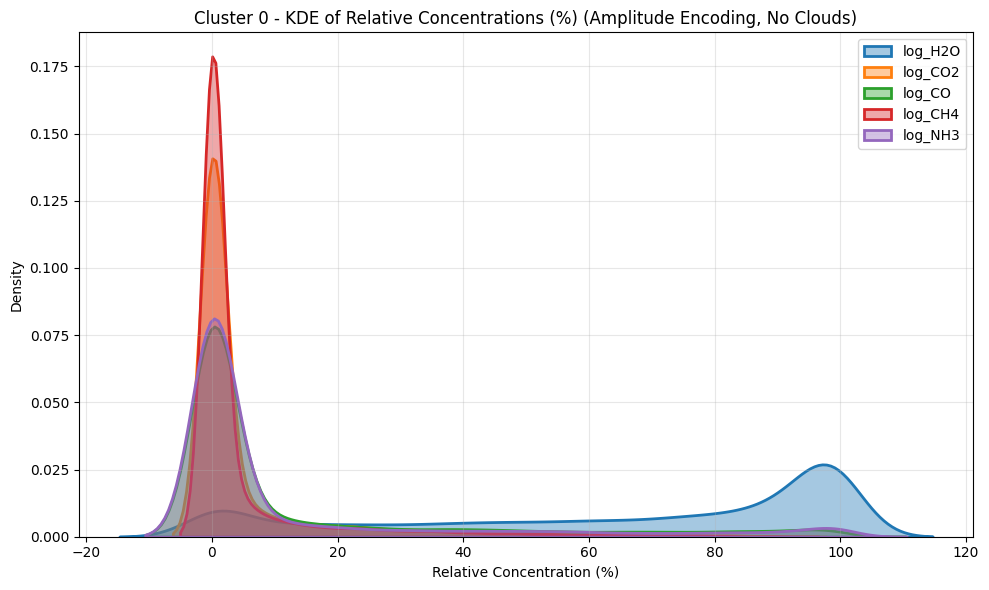

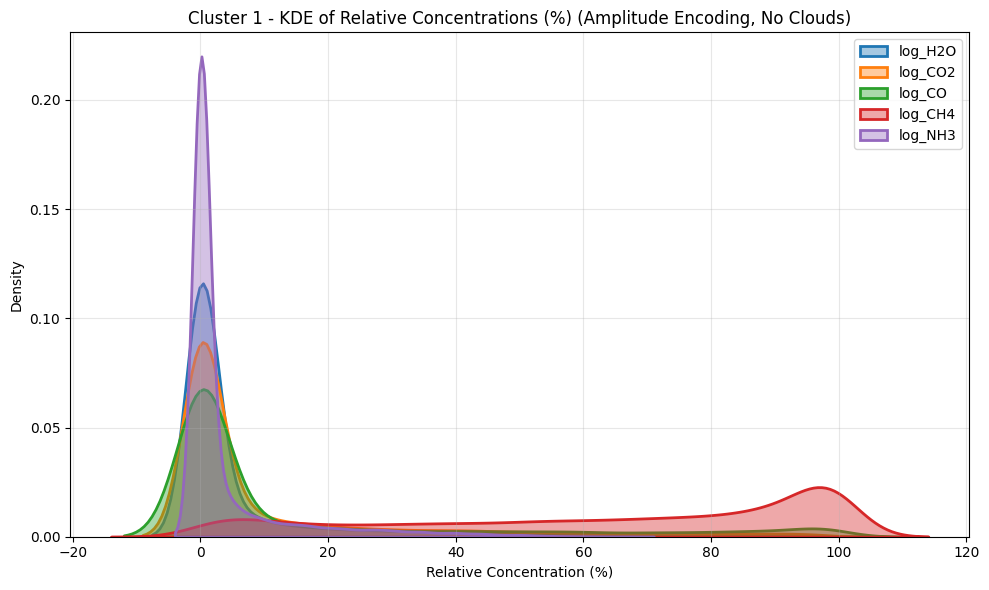

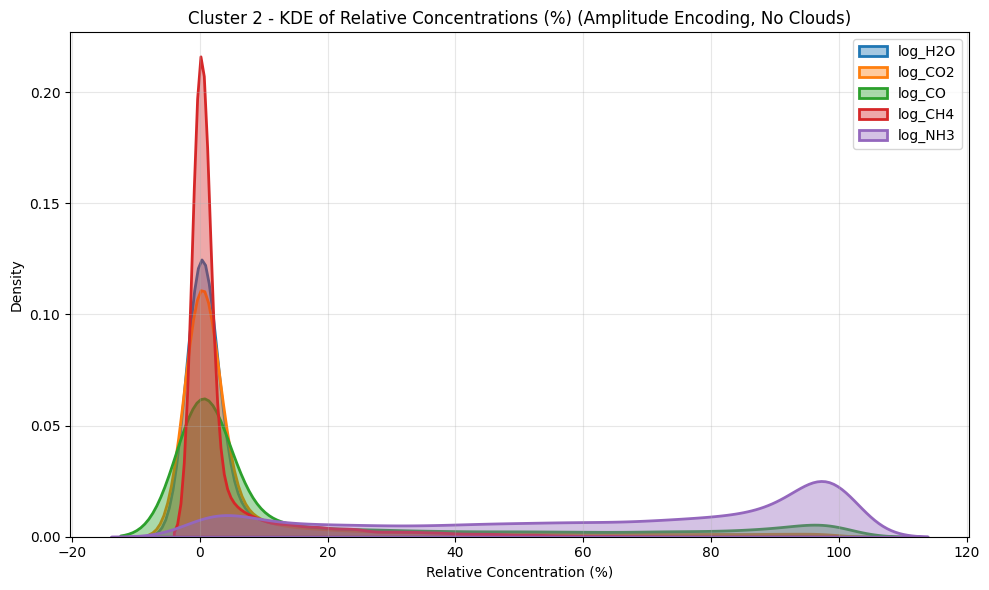

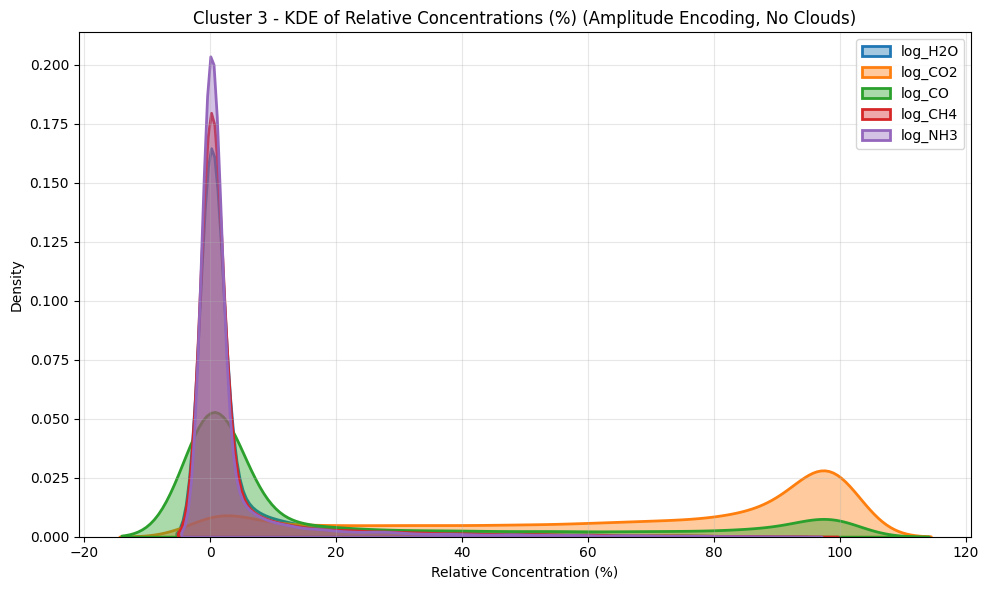

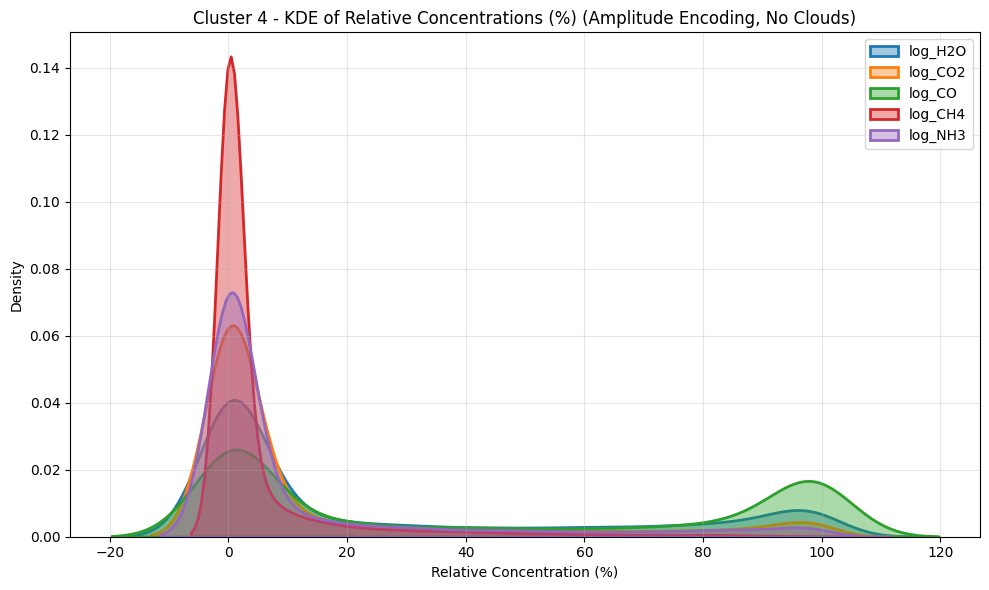

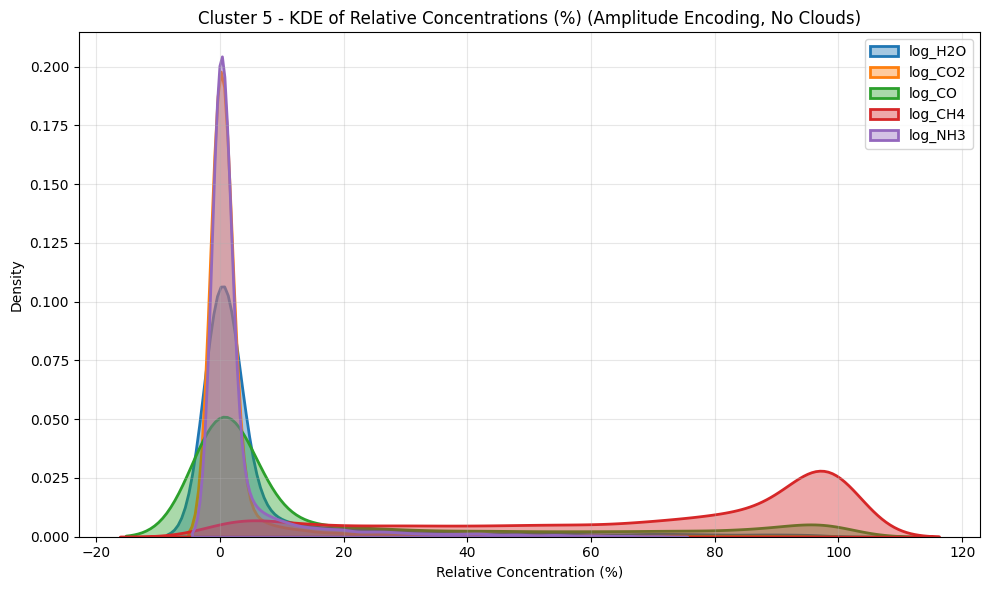

In [ ]:
for cluster_id in sorted(rel_df['cluster'].unique()):
    cluster_data = rel_df[rel_df['cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    for param in selected_params:
        values = cluster_data[param] * 100  # scale to %
        sns.kdeplot(values, label=param, fill=True, alpha=0.4, linewidth=2)

    plt.title(f"Cluster {cluster_id} - KDE of Relative Concentrations (%) (Amplitude Encoding, No Clouds)")
    plt.xlabel("Relative Concentration (%)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

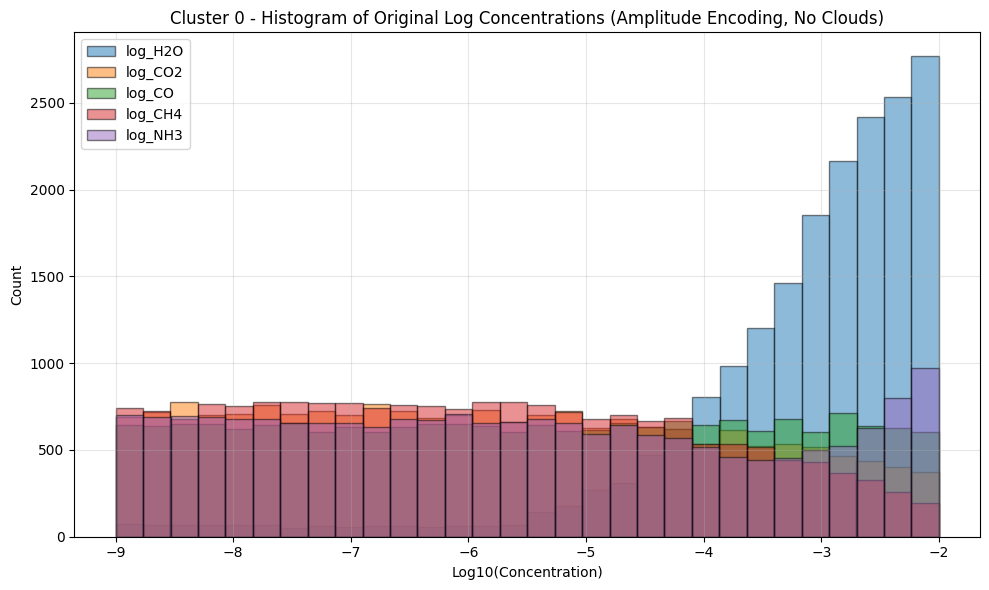

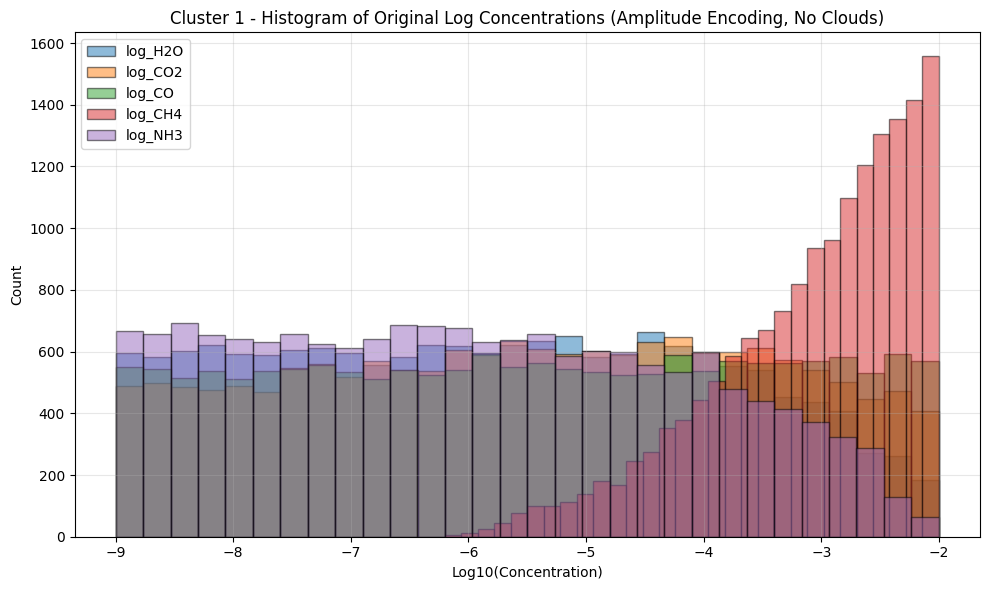

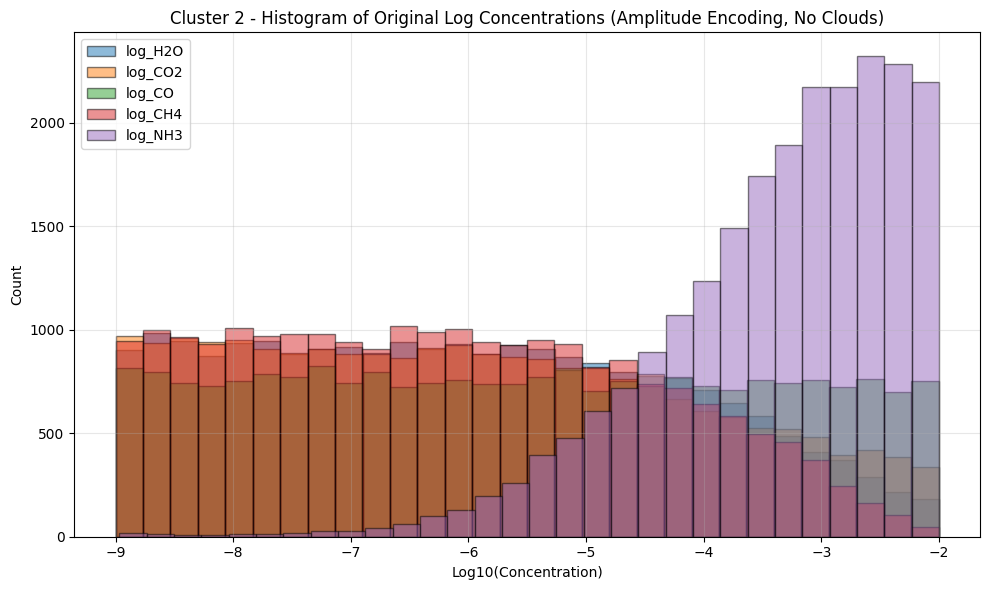

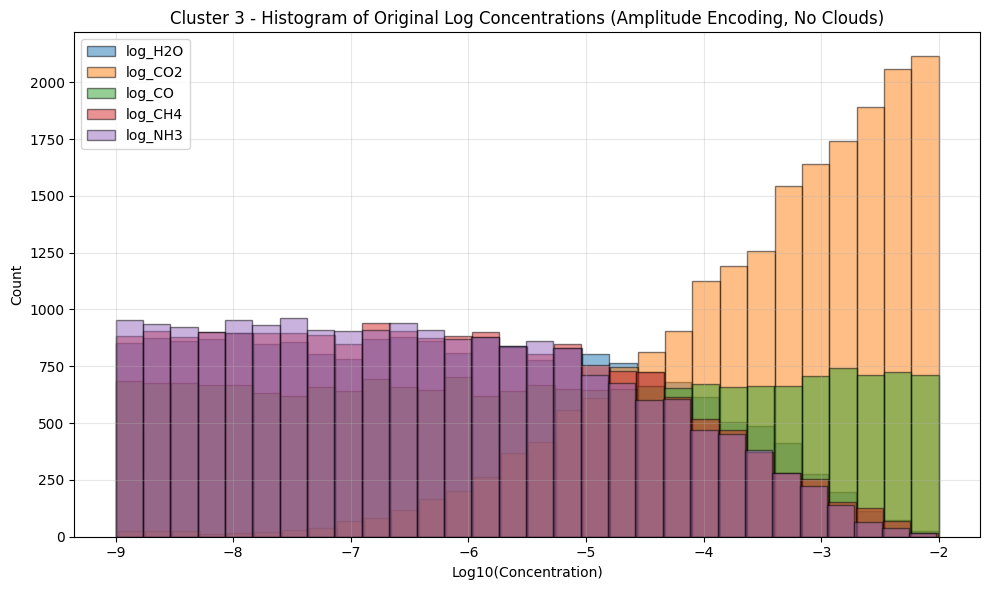

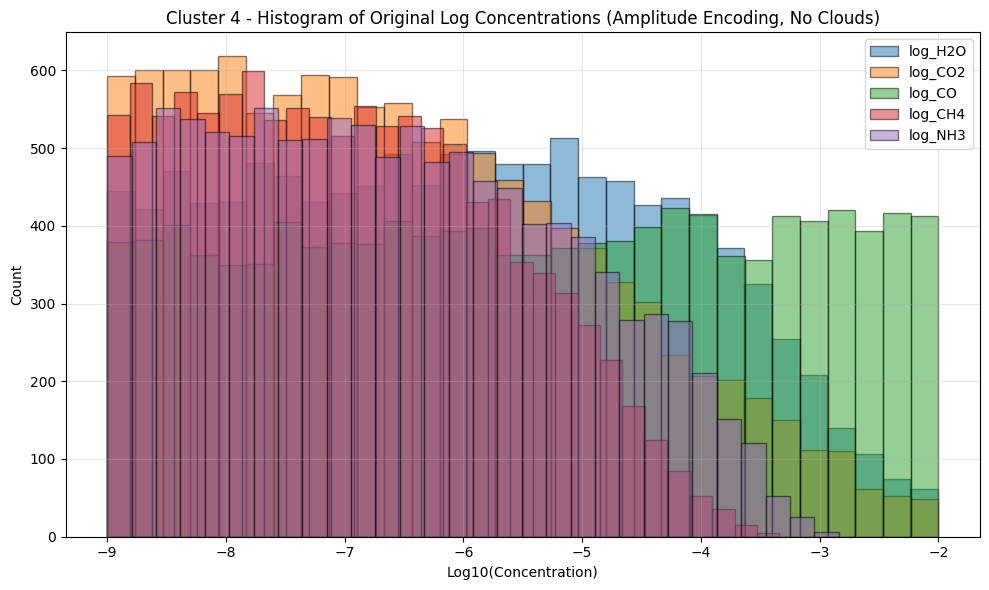

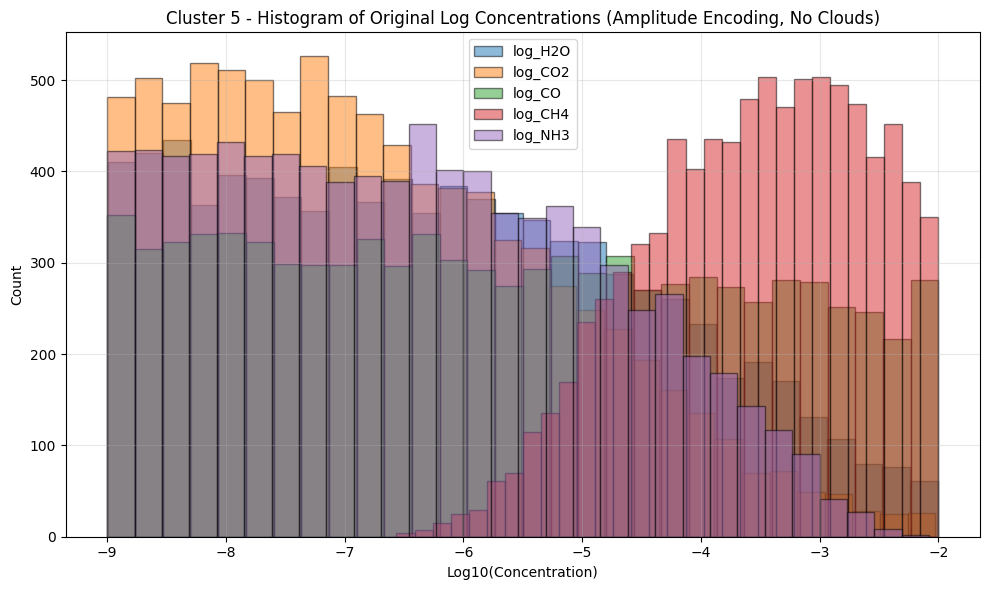

In [ ]:
# --- Histograms per cluster (absolute/log concentrations, amplitude encoding) ---
params_df = pd.DataFrame(params, columns=selected_params)
params_df['cluster'] = labels  # add cluster labels

for cluster_id in sorted(params_df['cluster'].unique()):
    cluster_data = params_df[params_df['cluster'] == cluster_id]

    plt.figure(figsize=(10, 6))
    for param in selected_params:
        plt.hist(cluster_data[param], bins=30, alpha=0.5, label=param, edgecolor='black')

    plt.title(f"Cluster {cluster_id} - Histogram of Original Log Concentrations (Amplitude Encoding, No Clouds)")
    plt.xlabel("Log10(Concentration)")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
filtered_rel_df = rel_df[rel_df[selected_params].max(axis=1) >= 0.70].copy()

print("Original shape:", rel_df.shape)
print("Filtered shape:", filtered_rel_df.shape)

# Display the first few rows
filtered_rel_df.head()

Original shape: (98664, 6)
Filtered shape: (70559, 6)


,log_H2O,log_CO2,log_CO,log_CH4,log_NH3,cluster
0,0.000002,0.130353,0.867895,1.841411e-05,0.001732,3
1,0.053839,0.828285,0.000424,6.122256e-02,0.056229,3
2,0.073854,0.926067,0.000029,8.986344e-07,0.000049,3
3,0.000007,0.942379,0.057484,9.676197e-05,0.000033,3
4,0.000173,0.837144,0.008102,2.461337e-02,0.129968,3


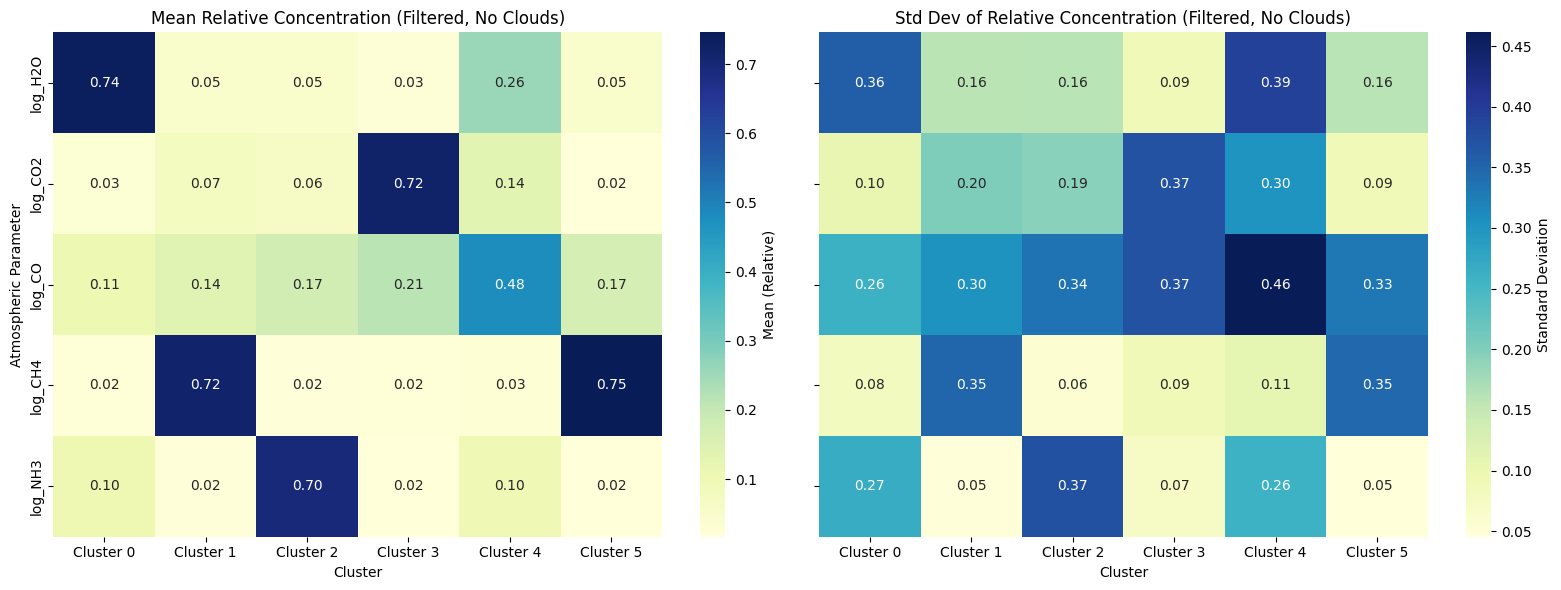

In [ ]:
#  Cluster means and stds on filtered subset
cluster_means = filtered_rel_df.groupby('cluster')[selected_params].mean()
cluster_stds = filtered_rel_df.groupby('cluster')[selected_params].std()

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Mean heatmap
sns.heatmap(cluster_means.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[0],
            xticklabels=[f'Cluster {i}' for i in cluster_means.index],
            yticklabels=selected_params, cbar_kws={'label': 'Mean (Relative)'})
axes[0].set_title("Mean Relative Concentration (Filtered, No Clouds)")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Atmospheric Parameter")

# Std deviation heatmap
sns.heatmap(cluster_stds.T, annot=True, fmt=".2f", cmap='YlGnBu', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in cluster_stds.index],
            yticklabels=selected_params, cbar_kws={'label': 'Standard Deviation'})
axes[1].set_title("Std Dev of Relative Concentration (Filtered, No Clouds)")
axes[1].set_xlabel("Cluster")

plt.tight_layout()
plt.show()